# Nearest-neighbour label correlation: Source (in vitro) ↔ Target (in vivo) endpoint correspondence

The current source and target share no molecules (0 by InChIKey), so labels of the same molecule cannot be compared directly.
Instead, look at the correlation between the labels of **each target molecule and its structurally most similar source molecule (1-NN)**.

- fingerprint: Morgan radius 2, 2048 bits (ECFP4) / similarity: Tanimoto
- Pearson r, Spearman ρ + bootstrap 95% CI per similarity threshold (≥0.3 … ≥0.8)

**Reference points (computed alongside)**
- **Within-target 1-NN correlation** = how similar the labels of structurally similar molecules are within the same endpoint → **upper bound**
  (if the source→target correlation is close to this, the endpoints correspond; if much lower, there is an endpoint difference that structural similarity does not explain)
- **Permutation null** = with source labels shuffled → should be ≈ 0

Caution: high-similarity pairs are few and may cluster in specific scaffold series → look at n and the CI together.

**Kernel: `esu_gpu (CUDA)`** (GPU not used, only RDKit and SciPy needed)

## 0. Settings

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from scipy.stats import pearsonr, spearmanr

RDLogger.DisableLog('rdApp.*')
ROOT = r'..'
NORM_DIR = os.path.join(ROOT, 'data', 'normalized_data')
OUT_DIR = os.path.join(ROOT, 'results', 'nn_label_correspondence')
os.makedirs(OUT_DIR, exist_ok=True)

PROPERTIES = ['clearance', 'half_life', 'fu']
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
MIN_N = 10            # skip the correlation when there are fewer pairs than this
N_BOOT = 1000
N_PERM = 200
RNG = np.random.default_rng(0)

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

## 1. Data

- source: `normalized_data/{prop}_source.csv` (log10 + Z-score per file) → **mean per molecule**
- target: `normalized_data/{prop}_target.csv` (log10)
- correlation coefficients are invariant to linear transforms, so different scales are comparable (but clearance z-scored ChEMBL and Biogen separately, so per-dataset results are shown too)

In [2]:
def fingerprints(smiles):
    fps, ok = [], []
    for s in smiles:
        m = Chem.MolFromSmiles(str(s))
        if m is not None:
            fps.append(fpgen.GetFingerprint(m))
            ok.append(True)
        else:
            ok.append(False)
    return fps, np.array(ok)


data = {}
for prop in PROPERTIES:
    src = pd.read_csv(os.path.join(NORM_DIR, f'{prop}_source.csv'), low_memory=False)
    # Dataset label: Biogen rows have an empty ChEMBL-only column (assay_id)
    src['dataset'] = np.where(src['assay_id'].notna(), 'ChEMBL', 'Biogen') if 'assay_id' in src else 'ChEMBL'
    src = src.groupby(['smiles', 'dataset'], as_index=False)['value'].mean()   # mean per molecule
    tgt = pd.read_csv(os.path.join(NORM_DIR, f'{prop}_target.csv')).groupby('smiles', as_index=False)['value'].mean()

    s_fps, s_ok = fingerprints(src['smiles'])
    t_fps, t_ok = fingerprints(tgt['smiles'])
    src, tgt = src[s_ok].reset_index(drop=True), tgt[t_ok].reset_index(drop=True)
    data[prop] = {'src': src, 'tgt': tgt, 's_fps': s_fps, 't_fps': t_fps}
    print(f'{prop:<10} source {len(src):>6} molecules {dict(src["dataset"].value_counts())} | target {len(tgt):>5} molecules')

clearance  source  13590 molecules {'ChEMBL': 10503, 'Biogen': 3087} | target  1027 molecules
half_life  source   8477 molecules {'ChEMBL': 8477} | target  1164 molecules
fu         source   3597 molecules {'ChEMBL': 3597} | target   353 molecules


## 2. Find nearest neighbours

- **cross**: target molecule → most similar source molecule
- **within-target**: target molecule → most similar other target molecule (upper-bound reference)

In [3]:
def nearest(query_fps, ref_fps, exclude_self=False):
    sims, idx = np.empty(len(query_fps)), np.empty(len(query_fps), dtype=int)
    for i, fp in enumerate(query_fps):
        s = np.array(DataStructs.BulkTanimotoSimilarity(fp, ref_fps))
        if exclude_self:
            s[i] = -1
        j = int(np.argmax(s))
        sims[i], idx[i] = s[j], j
    return sims, idx


pairs = {}
for prop in PROPERTIES:
    d = data[prop]
    rows = []
    for ds in ['all'] + sorted(d['src']['dataset'].unique()):
        mask = np.ones(len(d['src']), bool) if ds == 'all' else (d['src']['dataset'] == ds).to_numpy()
        if ds != 'all' and mask.all():
            continue  # with a single dataset this equals 'all'
        ref_fps = [f for f, m in zip(d['s_fps'], mask) if m]
        ref_y = d['src']['value'].to_numpy()[mask]
        sim, j = nearest(d['t_fps'], ref_fps)
        rows.append(pd.DataFrame({'kind': 'cross', 'source_set': ds, 'sim': sim,
                                  'y_target': d['tgt']['value'].to_numpy(), 'y_neighbor': ref_y[j]}))
    sim, j = nearest(d['t_fps'], d['t_fps'], exclude_self=True)
    y = d['tgt']['value'].to_numpy()
    rows.append(pd.DataFrame({'kind': 'within_target', 'source_set': '-', 'sim': sim, 'y_target': y, 'y_neighbor': y[j]}))
    pairs[prop] = pd.concat(rows, ignore_index=True)
    c = pairs[prop][(pairs[prop]['kind'] == 'cross') & (pairs[prop]['source_set'] == 'all')]
    print(f'{prop:<10} target→source max Tanimoto: median {c["sim"].median():.2f} | '
          + ' | '.join(f'≥{t}: {(c["sim"] >= t).sum()}' for t in THRESHOLDS))

clearance  target→source max Tanimoto: median 0.28 | ≥0.3: 407 | ≥0.4: 139 | ≥0.5: 70 | ≥0.6: 27 | ≥0.7: 7 | ≥0.8: 1
half_life  target→source max Tanimoto: median 0.26 | ≥0.3: 371 | ≥0.4: 125 | ≥0.5: 64 | ≥0.6: 30 | ≥0.7: 8 | ≥0.8: 1
fu         target→source max Tanimoto: median 0.28 | ≥0.3: 153 | ≥0.4: 85 | ≥0.5: 48 | ≥0.6: 16 | ≥0.7: 6 | ≥0.8: 0


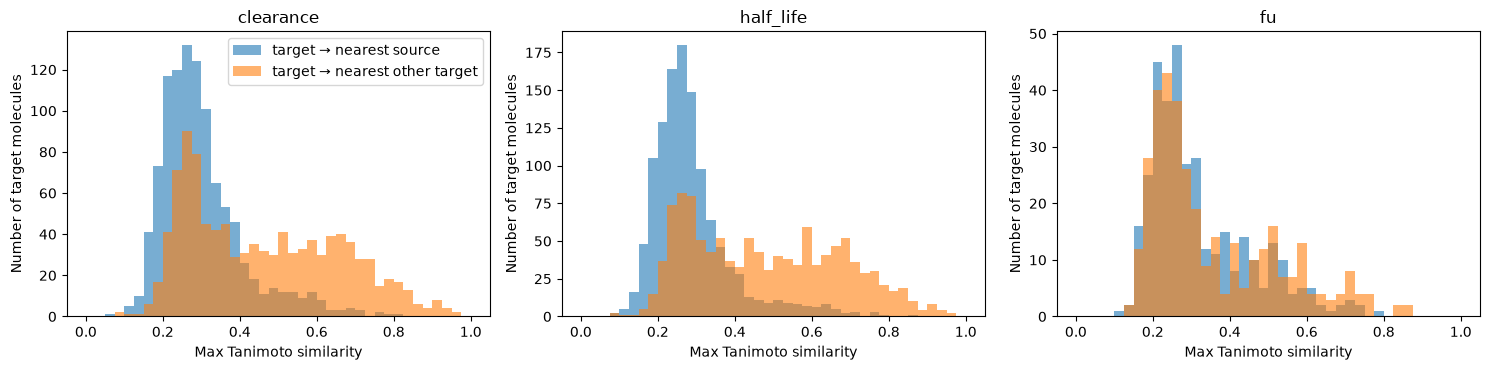

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, prop in zip(axes, PROPERTIES):
    p = pairs[prop]
    ax.hist(p[(p['kind'] == 'cross') & (p['source_set'] == 'all')]['sim'], bins=40, range=(0, 1), alpha=0.6, label='target → nearest source')
    ax.hist(p[p['kind'] == 'within_target']['sim'], bins=40, range=(0, 1), alpha=0.6, label='target → nearest other target')
    ax.set_title(prop)
    ax.set_xlabel('Max Tanimoto similarity')
    ax.set_ylabel('Number of target molecules')
axes[0].legend()
plt.tight_layout()
plt.show()

## 3. Label correlation per similarity threshold (bootstrap 95% CI, permutation null)

In [5]:
def corr_with_ci(x, y):
    n = len(x)
    r, rho = pearsonr(x, y)[0], spearmanr(x, y)[0]
    boot_r, boot_rho = [], []
    for _ in range(N_BOOT):
        i = RNG.integers(0, n, n)
        boot_r.append(pearsonr(x[i], y[i])[0])
        boot_rho.append(spearmanr(x[i], y[i])[0])
    return r, *np.nanpercentile(boot_r, [2.5, 97.5]), rho, *np.nanpercentile(boot_rho, [2.5, 97.5])


rows = []
for prop in PROPERTIES:
    for (kind, ds), p in pairs[prop].groupby(['kind', 'source_set']):
        for t in THRESHOLDS:
            q = p[p['sim'] >= t]
            row = {'property': prop, 'kind': kind, 'source_set': ds, 'threshold': t, 'n': len(q)}
            if len(q) >= MIN_N:
                x, y = q['y_target'].to_numpy(), q['y_neighbor'].to_numpy()
                r, r_lo, r_hi, rho, rho_lo, rho_hi = corr_with_ci(x, y)
                null = [spearmanr(x, RNG.permutation(y))[0] for _ in range(N_PERM)]
                row.update(pearson_r=r, r_lo=r_lo, r_hi=r_hi, spearman_rho=rho, rho_lo=rho_lo, rho_hi=rho_hi,
                           null_rho_95=np.percentile(np.abs(null), 95))
            rows.append(row)
res = pd.DataFrame(rows)
res.to_csv(os.path.join(OUT_DIR, 'nn_label_correlation.csv'), index=False)

view = res[res['source_set'].isin(['all', '-'])].pivot_table(
    index=['property', 'threshold'], columns='kind', values=['n', 'spearman_rho', 'pearson_r']).round(3)
view

n               pearson_r               spearman_rho  \
kind                 cross within_target     cross within_target        cross   
property  threshold                                                             
clearance 0.3        407.0         726.0     0.100         0.431        0.111   
          0.4        139.0         558.0     0.143         0.429        0.193   
          0.5         70.0         430.0     0.302         0.465        0.352   
          0.6         27.0         292.0     0.343         0.483        0.502   
          0.7          7.0         145.0       NaN         0.540          NaN   
          0.8          1.0          54.0       NaN         0.731          NaN   
fu        0.3        153.0         166.0     0.571         0.571        0.576   
          0.4         85.0         118.0     0.634         0.594        0.699   
          0.5         48.0          78.0     0.748         0.587        0.799   
          0.6         16.0          37.0     0.812         0.599        0.828   
          0.7          6.0          20.0       NaN         0.610          NaN   
          0.8          0.0           4.0       NaN           NaN          NaN   
half_life 0.3        371.0         872.0     0.063         0.476        0.008   
          0.4        125.0         684.0     0.090         0.513        0.047   
          0.5         64.0         525.0     0.105         0.544        0.095   
          0.6         30.0         361.0     0.119         0.585        0.099   
          0.7          8.0         186.0       NaN         0.727          NaN   
          0.8          1.0          64.0       NaN         0.792          NaN   

                                   
kind                within_target  
property  threshold                
clearance 0.3               0.477  
          0.4               0.468  
          0.5               0.511  
          0.6               0.514  
          0.7               0.568  
          0.8               0.744  
fu        0.3               0.619  
          0.4               0.637  
          0.5               0.602  
          0.6               0.636  
          0.7               0.713  
          0.8                 NaN  
half_life 0.3               0.509  
          0.4               0.547  
          0.5               0.575  
          0.6               0.618  
          0.7               0.745  
          0.8               0.800

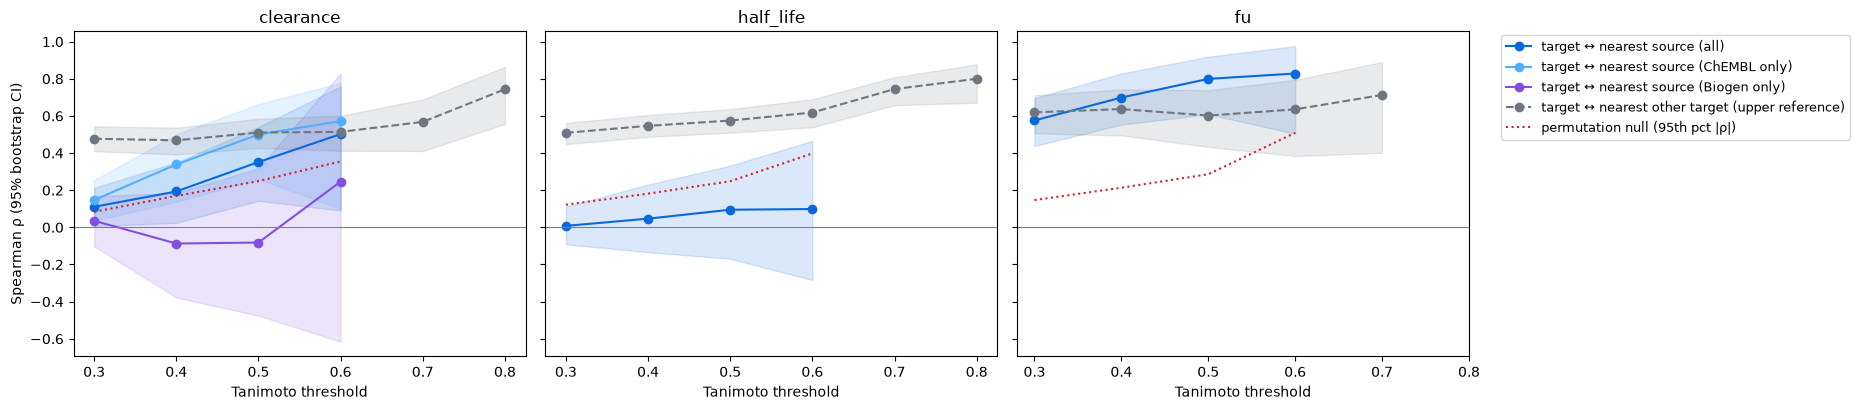

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
styles = {('cross', 'all'): ('#0969da', 'target ↔ nearest source (all)'),
          ('cross', 'ChEMBL'): ('#54aeff', 'target ↔ nearest source (ChEMBL only)'),
          ('cross', 'Biogen'): ('#8250df', 'target ↔ nearest source (Biogen only)'),
          ('within_target', '-'): ('#6e7781', 'target ↔ nearest other target (upper reference)')}
for ax, prop in zip(axes, PROPERTIES):
    for (kind, ds), (color, label) in styles.items():
        q = res[(res['property'] == prop) & (res['kind'] == kind) & (res['source_set'] == ds)].dropna(subset=['spearman_rho'])
        if q.empty:
            continue
        ls = '--' if kind == 'within_target' else '-'
        ax.plot(q['threshold'], q['spearman_rho'], marker='o', color=color, ls=ls, label=label)
        ax.fill_between(q['threshold'], q['rho_lo'], q['rho_hi'], color=color, alpha=0.15)
    q = res[(res['property'] == prop) & (res['kind'] == 'cross') & (res['source_set'] == 'all')].dropna(subset=['null_rho_95'])
    ax.plot(q['threshold'], q['null_rho_95'], color='#cf222e', ls=':', label='permutation null (95th pct |ρ|)')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title(prop)
    ax.set_xlabel('Tanimoto threshold')
    ax.set_xticks(THRESHOLDS)  # same ticks across panels
axes[0].set_ylabel('Spearman ρ (95% bootstrap CI)')
# Panels draw different lines (ChEMBL/Biogen only for clearance), so collect the lines from all panels into one legend
legend = {}
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        legend.setdefault(l, h)
fig.legend(legend.values(), legend.keys(), bbox_to_anchor=(1.0, 0.92), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Scatter plot (Tanimoto ≥ 0.5)

One point = a target molecule paired with its nearest source molecule.

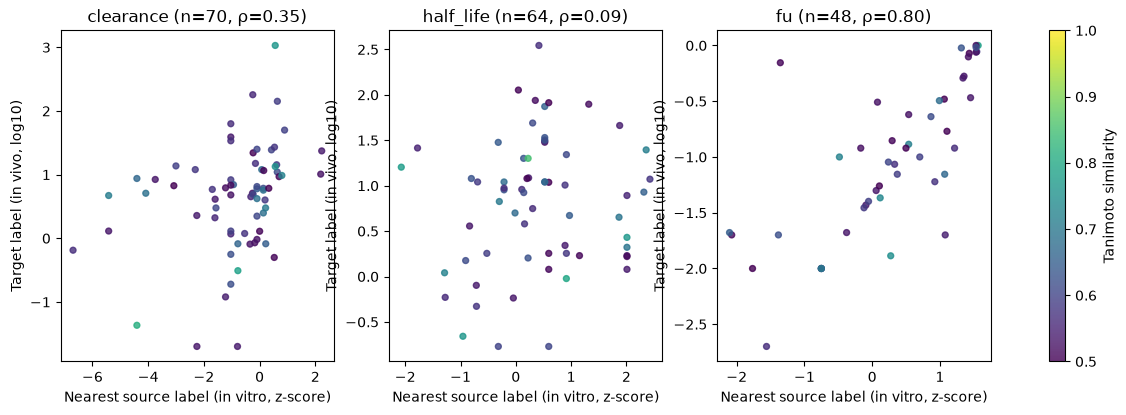

In [7]:
SCATTER_T = 0.5
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, prop in zip(axes, PROPERTIES):
    p = pairs[prop]
    q = p[(p['kind'] == 'cross') & (p['source_set'] == 'all') & (p['sim'] >= SCATTER_T)]
    sc = ax.scatter(q['y_neighbor'], q['y_target'], c=q['sim'], cmap='viridis', vmin=SCATTER_T, vmax=1, s=18, alpha=0.8)
    if len(q) >= MIN_N:
        ax.set_title(f'{prop} (n={len(q)}, ρ={spearmanr(q["y_target"], q["y_neighbor"])[0]:.2f})')
    else:
        ax.set_title(f'{prop} (n={len(q)})')
    ax.set_xlabel('Nearest source label (in vitro, z-score)')
    ax.set_ylabel('Target label (in vivo, log10)')
fig.colorbar(sc, ax=axes, label='Tanimoto similarity')
plt.show()

## 5. Interpretation guide

| Result pattern | Interpretation |
|---|---|
| cross ρ ≈ within-target ρ (CIs overlap) | in vitro and in vivo endpoints correspond as far as structural similarity allows |
| cross ρ > null but clearly below within-target | partial correspondence — endpoint differences exist (non-metabolic routes, protein binding, etc.) |
| cross ρ ≈ null | no evidence of correspondence in this similarity range |
| n < 30 at high thresholds | withhold conclusions (wide CI, possibly biased towards specific series) |

Caution: 1-NN pairs are different molecules, so this analysis **does not replace an in vitro–in vivo correlation (IVIVC) on the same molecules.** It is an indirect indicator of "whether the two endpoints move in the same direction between structurally similar molecules".